In [1]:
import numpy as np
from scipy.optimize import fsolve
from scipy.integrate import solve_ivp
import sys
from pathlib import Path
import importlib
# add Modeling/ to Python path
project_root = Path.cwd().parents[2]
sys.path.append(str(project_root))
from Modeling.models.plotting import animate_field_1d
from Modeling.models.beam_properties import PiezoBeamParams

import matplotlib.pyplot as plt
# from Modeling.models.ROM import ROM

import Modeling.models.FE1 as FE1_module
importlib.reload(FE1_module)
FE1 = FE1_module
import Modeling.models.ROM as ROM_module
importlib.reload(ROM_module)
ROM = ROM_module.ROM

# from FE1 import PiezoBeamFE, frf_sweep, solve_newmark
import numpy as np
from numpy import pi	
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from IPython.display import clear_output
from matplotlib import cm, colors
import pandas as pd
from joblib import Parallel, delayed
import matplotlib.pyplot as plt

X shape: (901,) Y shape: (901, 157) freq shape: (901,) veloc shape: (901, 157)


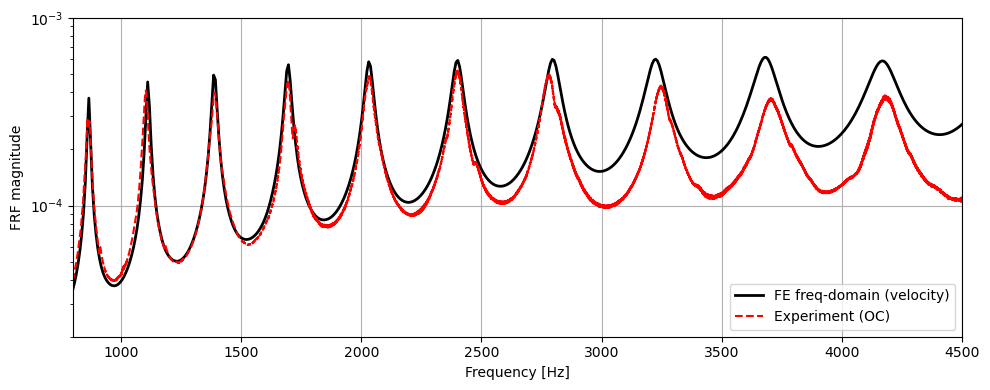

In [2]:

K_i = 1800; K_p = 0.0025; K_c = 0; R_c = 1e3
K_i = 0; K_p = 5000; K_c = 0; R_c = 1e3
K_i = 0; K_p = 1e-5; K_c = 0; R_c = 1e3
t_end = 0.01
f0 = 800
f1 = 4500
dt = 1/f1/20
def v_exc(t, A_exc=50, f0=f0, f1=f1, t_end=t_end):
	return A_exc*np.sin(2*np.pi*(f0+ t*(f1-f0)/t_end) *t)
# N = 40
# hp, hs = 0.31e-3, 0.607e-3 		
params_fe = PiezoBeamParams(
                            hp=0.252e-3, hs=0.51e-3
                            # hp=0.31e-3, hs=0.607e-3
                            , d31= -1.48e-10,eps_r=1700
                            )
params_fe.zeta_p = 0.0151*8
params_fe.zeta_q = 0.0392*10

# params_fe.zeta_p = 0.0151*8
# params_fe.zeta_q = 0.0392*4

fe = FE1.PiezoBeamFE(params_fe)
ode = fe.build_ode_system(
    j_exc=30,
    K_c=K_c,    # linear circuit
    K_i=K_i,
    K_p= K_p,
	v_exc=v_exc
)
f_fe = np.linspace(f0, f1, 500)
frf_fd = FE1.frf_sweep(ode, f_fe*2*pi)
N = ode.N_mech
w_fd = frf_fd['u']
w_dot_fd = frf_fd['u_dot']


# time grid and ICs
t_eval = np.arange(0, t_end, dt)
ndof = ode.M.shape[0]

x0 = np.zeros(ndof)
x_dot0 = np.zeros(ndof)

result = FE1.solve_newmark(
	ode=ode,
	dt=dt,
	t_end=t_end,
	beta=0.25,
	gamma=0.5,
	newton_tol=1e-8,
	newton_maxiter=8,
	x0=x0,
	x_dot0=x_dot0
	)

# Extract results from dictionary
t = result['t']
w = result['u']                # mechanical displacement
w_dot = result['u_dot']        # mechanical velocity
w_ddot = result['u_ddot']      # mechanical acceleration
q = result['q']                # electrical charge
v = result['v']                # voltage
spec_td = result['spectral']   # time-domain FRF dictionary (freq, FRF)
# Frequency-domain vs time-domain FRF overlay with experimental/COMSOL
try:
    # Load experimental datasets (same as FE_OC)
    npz_path_OC = r"Z:\Nima\Synthetic_impedance\long_beam\ssdsl_dat\ssdsl_dat_Nov\11\OC.npz".replace("\\", "/")
    npz_path_SC = r"Z:\Nima\Synthetic_impedance\long_beam\ssdsl_dat\ssdsl_dat_Nov\7\kc0_kp_sweep\OCSC\SC.npz".replace("\\", "/")
    npz_path_OC = r"Z:\Nima\Synthetic_impedance\long_beam\ssdsl_dat\ssdsl_dat_Nov\7\kc0_kp_sweep\OCSC\OC.npz".replace("\\", "/")
    npz_path_linear = r"Z:\Nima\Synthetic_impedance\long_beam\ssdsl_dat\ssdsl_dat_Nov\11\linear_lowdamping.npz".replace("\\", "/")
    data_OC = np.load(npz_path_OC)
    data_SC = np.load(npz_path_SC)
    data_linear = np.load(npz_path_linear)
    frq_OC_exp = data_OC['freq']
    frf_OC_exp = data_OC['frf_data']  # (Nfiles, Nfreq, Npoints)
    frq_SC_exp = data_SC['freq']
    frf_SC_exp = data_SC['frf_data']
    frq_linear_exp = data_linear['freq']
    frf_linear_exp = data_linear['frf_data']
except Exception as e:
    print("Experimental data not loaded:", e)
    frq_OC_exp = frf_OC_exp = frq_SC_exp = frf_SC_exp = frq_linear_exp = frf_linear_exp = None

# COMSOL reference
try:
    comsol = pd.read_csv('../../../comsol/LR.csv')
    # comsol = pd.read_csv('../../../comsol/SC.csv')
except Exception as e:
    print("COMSOL data not loaded:", e)
    comsol = None

# Frequency-domain FE FRF (velocity magnitude averaged over transverse DOFs)
freq_fd = frf_fd['freq']
vel_fd = np.mean(np.abs(w_dot_fd), axis=1)

# Time-domain FRF from transient (if available)
if spec_td is not None and spec_td['freq'] is not None:
    freq_td = spec_td['freq']
    frf_td = spec_td['FRF']
else:
    freq_td = None
    frf_td = None

plt.figure(figsize=(10, 4))

# plt.semilogy(comsol['freq'], comsol['w']*2*np.pi*comsol['freq'], 'g-', label='COMSOL')
# plt.semilogy(frq_linear_exp, np.mean(frf_linear_exp, axis=1), 'r--', label='Experiment (linear)')
plt.semilogy(freq_fd, vel_fd/1.2,'k-' , lw=2, label='FE freq-domain (velocity)')
plt.semilogy(frq_OC_exp, np.mean(frf_OC_exp, axis=1), 'r--', label='Experiment (OC)')
# plt.semilogy(frq_SC_exp, np.mean(frf_SC_exp, axis=1), 'r--', label='Experiment (SC)')
# plt.semilogy(freq_td, frf_td/1.5, '.-', label='FE time-domain (velocity)')
plt.xlabel('Frequency [Hz]')
plt.ylabel('FRF magnitude')
plt.xlim([1000, 3000])
plt.xlim([f0, f1])
plt.ylim([2e-5, 1e-3])
plt.grid(True)
plt.legend()
# plt.title('FRF overlay: experimental, COMSOL, FE (freq), FE (time)')
plt.tight_layout()
plt.show()


In [3]:
fe.M.shape
ode.M.shape
ode.N_elec
kc0 = 1e10; kc1 = -1e10
K_c = [kc0, kc1]*15
K_c
ode.f_int(np.zeros(ode.M.shape[0])).shape

(344,)

In [4]:
%matplotlib widget

In [6]:
kc0 = 6e10
gamma = 0.5
ki= 1800
ki0 = (1-gamma)*ki; ki1 = (1+gamma)*ki
K_i = 1800; K_p = 0.03; K_c = -1.6e10 ; R_c = 1e3
K_c = np.array([kc0, -kc0]*15)
K_i = np.array([ki0, ki1]*15+[ki0])
t_end = 1.0
f0 = 1000
f1 = 3000
dt = 1/f1/50
from joblib import Parallel, delayed
# Create excitation function factory
def make_v_exc(A):
	def v_exc(t_var, A_exc=A, f0=f0, f1=f1, t_end=t_end):
		return A_exc * np.sin(2*np.pi*(f0 + t_var*(f1-f0)/t_end) * t_var)
	return v_exc

# ...existing code...
# Function to run single amplitude simulation
def run_amplitude_case(A, fe, params, K_c, K_i, K_p, dt, t_end):
    """Run one simulation for given excitation amplitude A with error handling."""
    try:
        print(f"  Amplitude = {A}")
        v_exc = make_v_exc(A)
        ode = fe.build_ode_system(
            j_exc=30,
            K_c=K_c,
            K_i=K_i,
            K_p=K_p,
            R_c=R_c,
            v_exc=v_exc
        )
        result = FE1.solve_newmark(
            ode=ode,
            dt=dt,
            t_end=t_end,
            beta=0.25,
            gamma=0.5,
            newton_tol=1e-8,
            newton_maxiter=10,
            x0=np.zeros(ode.M.shape[0]),
            x_dot0=np.zeros(ode.M.shape[0]),
            do_spectral=True
        )
        return {
            "status": "ok",
            "A": A,
            "freq": result['spectral']['freq'],
            "FRF": result['spectral']['FRF'],
            "Spectral": result['spectral'],
            "velocity": result['u_dot'],
            "voltage": result['v'],
            't': result['t']
        }
    except Exception as e:
        return {
            "status": "failed",
            "A": A,
            "error": str(e),
            "exception": type(e).__name__
        }

# Amplitude sweep parameters
A_list = np.linspace(5, 50, 8)  # excitation amplitudes
# A_list = [50]
print(f"Running amplitude sweep for A = {A_list}...")

# Run in parallel
raw_results = Parallel(n_jobs=16, verbose=10)(
    delayed(run_amplitude_case)(A, fe, params_fe, K_c, K_i, K_p, dt, t_end)
    for A in A_list
)

# Separate successes and failures
sweep_results = [r for r in raw_results if r["status"] == "ok"]
failed = [r for r in raw_results if r["status"] == "failed"]

# ...existing code...
print("Amplitude sweep completed!")
print(f"  Successful: {len(sweep_results)} / {len(raw_results)}")
if failed:
    print("  Failed cases:")
    for f in failed:
        print(f"    A={f['A']}: {f['exception']} -> {f['error']}")

# ======= Save results (unique filename by Ki, gamma, Kc) =======
import hashlib
import json

def short_hash(arr):
    arr_np = np.asarray(arr, dtype=float)
    return hashlib.sha1(arr_np.tobytes()).hexdigest()[:8]

# Tags based on varying params
kc_abs0 = float(np.abs(np.asarray(K_c, dtype=float)[0]))
kc_hash = short_hash(K_c)
ki_nom = float(ki) if 'ki' in globals() else float(np.mean(np.asarray(K_i, dtype=float)))
ki_hash = short_hash(K_i)
gamma_tag = float(gamma) if 'gamma' in globals() else 0.0

# Build filename
npz_name = f"FE_amp_sweep_alter_Ki={ki_nom:.0f}_gamma={gamma_tag:.3f}_Kc={kc_abs0:.2e}_{kc_hash}.npz"

# Output dir
sim_dat_dir = Path.cwd() / 'sim_dat'
sim_dat_dir.mkdir(parents=True, exist_ok=True)

# Pack everything
np.savez(sim_dat_dir / npz_name,
         # sweep outputs
         amp_list=A_list,
         sweep_results=np.array(sweep_results, dtype=object),
         failed=np.array(failed, dtype=object),
         # spectral convenience arrays (first successful case)
         sample_freq=(sweep_results[0]['freq'] if sweep_results else None),
         # parameters
         K_p=K_p,
         K_i=np.asarray(K_i, dtype=float),
         K_i_nominal=ki_nom,
         K_i_hash=ki_hash,
         gamma=gamma_tag,
         K_c=np.asarray(K_c, dtype=float),
         K_c_abs0=kc_abs0,
         K_c_hash=kc_hash,
         R_c=R_c,
         t_end=t_end,
         f0=f0,
         f1=f1,
         dt=dt,
         # FE model parameters
         params_fe_hp=params_fe.hp,
         params_fe_hs=params_fe.hs,
         params_fe_d31=params_fe.d31,
         params_fe_eps_r=params_fe.eps_r,
         params_fe_zeta_p=params_fe.zeta_p,
         params_fe_zeta_q=params_fe.zeta_q)

print(f"Results saved to: {sim_dat_dir / npz_name}")

# Optional: save error log JSON
if failed:
    err_name = f"FE_1D_amp_sweep_errors_Ki={ki_nom:.0f}_gamma={gamma_tag:.3f}_Kc={kc_abs0:.2e}_{kc_hash}.json"
    error_log = {
        "total": len(raw_results),
        "successful": len(sweep_results),
        "failed": len(failed),
        "failed_cases": failed,
        "tags": {
            "Ki_nominal": ki_nom,
            "gamma": gamma_tag,
            "Kc_abs0": kc_abs0,
            "Kc_hash": kc_hash
        }
    }
    with open(sim_dat_dir / err_name, "w") as f:
        json.dump(error_log, f, indent=2)
    print(f"Error log saved to: {sim_dat_dir / err_name}")
# ...existing code...

Running amplitude sweep for A = [ 5.         11.42857143 17.85714286 24.28571429 30.71428571 37.14285714
 43.57142857 50.        ]...


[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done   2 out of   8 | elapsed:  4.9min remaining: 14.7min
[Parallel(n_jobs=16)]: Done   3 out of   8 | elapsed:  4.9min remaining:  8.2min
[Parallel(n_jobs=16)]: Done   4 out of   8 | elapsed:  5.0min remaining:  5.0min
[Parallel(n_jobs=16)]: Done   5 out of   8 | elapsed:  5.0min remaining:  3.0min
[Parallel(n_jobs=16)]: Done   6 out of   8 | elapsed:  5.2min remaining:  1.7min
[Parallel(n_jobs=16)]: Done   8 out of   8 | elapsed:  5.2min finished


Amplitude sweep completed!
  Successful: 8 / 8
Results saved to: c:\Users\setemadi3\GaTech Dropbox\Seyednima Etemadi\Projects\Metamaterial beam\Modeling\tasks\FE_studies\sim_dat\FE_amp_sweep_alter_Ki=1800_gamma=0.500_Kc=6.00e+10_5ac7f7dc.npz


In [3]:
# Load saved amplitude sweep data
import hashlib

def short_hash(arr):
    arr_np = np.asarray(arr, dtype=float)
    return hashlib.sha1(arr_np.tobytes()).hexdigest()[:8]

# Reconstruct filename (use same parameters as when saving)
# kc_abs0 = float(np.abs(np.asarray(K_c, dtype=float)[0]))
kc_abs0 = 6e10
kc_hash = short_hash(K_c)
ki_nom = float(ki) if 'ki' in globals() else float(np.mean(np.asarray(K_i, dtype=float)))
gamma_tag = float(gamma) if 'gamma' in globals() else 0.0

npz_name = f"FE_amp_sweep_alter_Ki={ki_nom:.0f}_gamma={gamma_tag:.3f}_Kc={kc_abs0:.2e}_{kc_hash}.npz"
npz_name = 'FE_amp_sweep_alter_Ki=1800_gamma=0.500_Kc=6.00e+10_5ac7f7dc.npz'
# npz_name = 'FE_2D_sweep_amp_gamma_Kp=0.030_Ki=1800_Kc=6.00e+10_5ac7f7dc.npz'
npz_path = Path.cwd() / 'sim_dat' / npz_name

# Load data
data = np.load(npz_path, allow_pickle=True)

# Extract arrays
A_list = data['amp_list']
sweep_results = data['sweep_results']
failed = data['failed']
K_i = data['K_i']
K_c = data['K_c']
K_p = data['K_p']

print(f"Loaded data from: {npz_path}")
print(f"\nAmplitudes: {A_list}")
print(f"Successful cases: {len(sweep_results)}")
print(f"Failed cases: {len(failed)}")
print(f"\nParameters:")
print(f"  K_i (nominal): {data['K_i_nominal']:.0f}")
print(f"  gamma: {data['gamma']:.3f}")
print(f"  K_c (abs): {data['K_c_abs0']:.2e}")
print(f"  K_p: {K_p:.4f}")
print(f"  Frequency range: {data['f0']:.0f} - {data['f1']:.0f} Hz")
print(f"  Time span: {data['t_end']:.2f} s")

# Access sweep results
# sweep_results_loaded is an array of dicts, each with keys: 'A', 'freq', 'FRF', 'Spectral', etc.

Loaded data from: c:\Users\setemadi3\GaTech Dropbox\Seyednima Etemadi\Projects\Metamaterial beam\Modeling\tasks\FE_studies\sim_dat\FE_amp_sweep_alter_Ki=1800_gamma=0.500_Kc=6.00e+10_5ac7f7dc.npz

Amplitudes: [ 5.         11.42857143 17.85714286 24.28571429 30.71428571 37.14285714
 43.57142857 50.        ]
Successful cases: 8
Failed cases: 0

Parameters:
  K_i (nominal): 1800
  gamma: 0.500
  K_c (abs): 6.00e+10
  K_p: 0.0300
  Frequency range: 1000 - 3000 Hz
  Time span: 1.00 s


In [32]:
# print(data.keys())
print(sweep_results[0].keys())

dict_keys(['status', 'A', 'freq', 'FRF', 'Spectral', 'velocity', 'voltage', 't'])


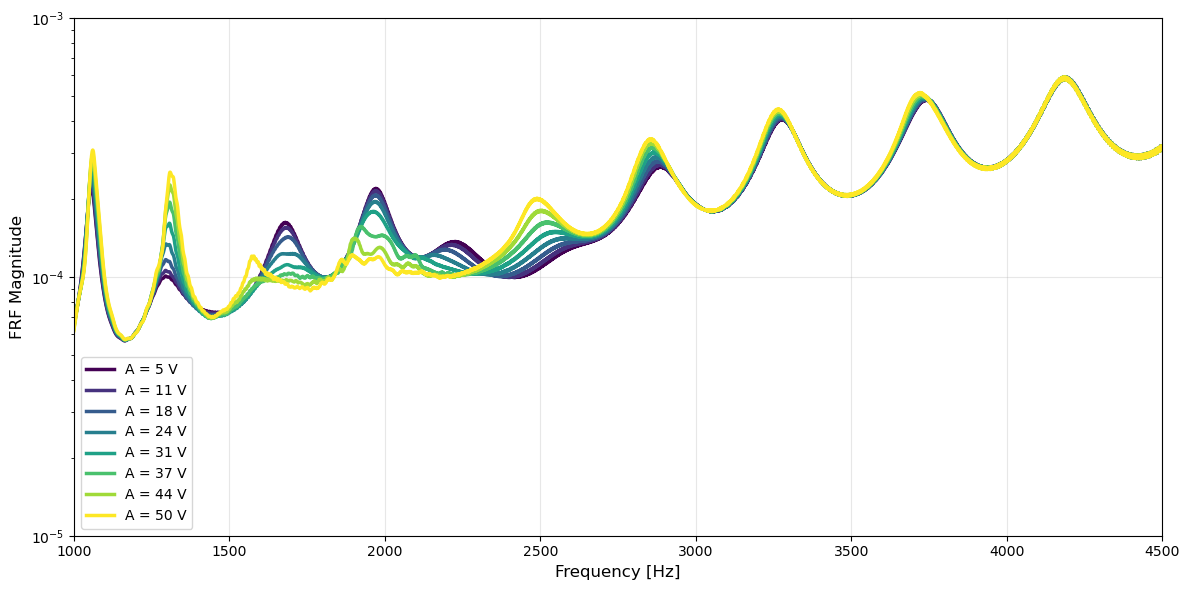

In [33]:

# Plot FRF overlay with color gradient
plt.figure(figsize=(12, 6))
cmap = plt.cm.viridis
colors_amp = cmap(np.linspace(0, 1, len(A_list)))

for i, result in enumerate(sweep_results):
	A = result['A']
	freq = result['freq']
	frf = result['FRF']
	plt.semilogy(freq, frf, '-', linewidth=2.5, 
				label=f'A = {A:0.0f} V', color=colors_amp[i])

plt.xlabel('Frequency [Hz]', fontsize=12)
plt.ylabel('FRF Magnitude', fontsize=12)
plt.xlim([1000, 4500])
plt.ylim([1e-5, 1e-3])
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10, loc='best')
# plt.title(f'FRF vs Excitation Amplitude (Kc={K_c:.1e}, Ki={K_i:.0f}, Kp={K_p:.4f})', 
# 		fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
fe.x_nodes.shape
sweep_results[0]['velocity'].shape

(150001, 157)

In [19]:
sweep_results[0].keys()
# sweep_results[0]['freq']

dict_keys(['status', 'A', 'freq', 'FRF', 'Spectral', 'velocity', 'voltage'])

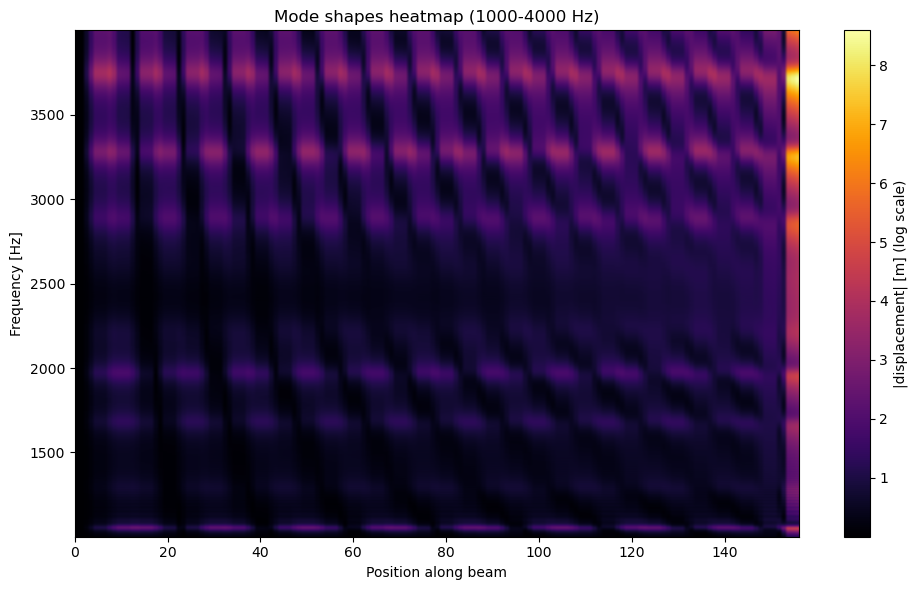

In [34]:
amp_idx = 0  # Example: get results for 4th amplitude
mode_shapes = sweep_results[amp_idx]['Spectral']['Y']
# Convert complex displacement to magnitude
mode_mag = np.abs(mode_shapes)  # (Nfreq, Ndof)

# Node positions
try:
    x_nodes = fe.node_coords.squeeze()
except AttributeError:
    x_nodes = np.arange(mode_mag.shape[1])
freq_axis = sweep_results[amp_idx]['freq']

from matplotlib.colors import LogNorm

# Frequency mask: confine to region of interest
freq_min = 1000  # Hz
freq_max = 4000  # Hz
freq_mask = (freq_axis >= freq_min) & (freq_axis <= freq_max)
freq_idx = np.where(freq_mask)[0]

if len(freq_idx) == 0:
    print(f"No frequencies found in range [{freq_min}, {freq_max}]. Available range: [{freq_axis.min():.0f}, {freq_axis.max():.0f}]")
else:
    # Extract masked data
    mode_mag_masked = mode_mag[freq_mask, :]
    freq_axis_masked = freq_axis[freq_mask]
    
    # Log-scale color axis with safe vmin/vmax
    vmin = max(np.min(mode_mag_masked[mode_mag_masked > 0]), 1e-12) if np.any(mode_mag_masked > 0) else 1e-12
    vmax = mode_mag_masked.max() if mode_mag_masked.size else 1
    
    plt.figure(figsize=(10, 6))
    im = plt.imshow(
        mode_mag_masked,
        aspect='auto',
        origin='lower',
        extent=[x_nodes.min(), x_nodes.max(), freq_axis_masked.min(), freq_axis_masked.max()],
        cmap='inferno',
        # norm=LogNorm(vmin=vmin, vmax=vmax)
    )
    plt.colorbar(im, label='|displacement| [m] (log scale)')
    plt.xlabel('Position along beam')
    plt.ylabel('Frequency [Hz]')
    plt.title(f'Mode shapes heatmap ({freq_min}-{freq_max} Hz)')
    plt.tight_layout()
    plt.show()

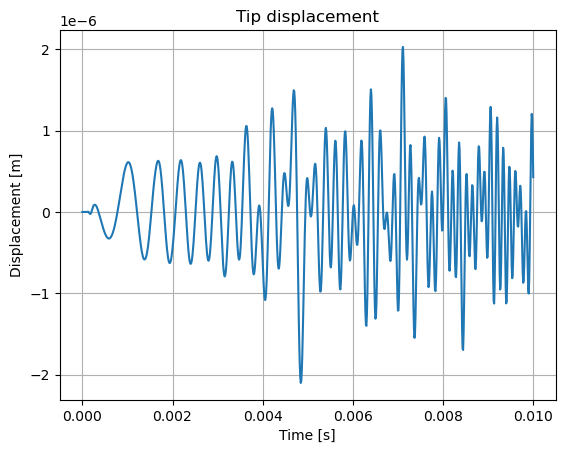

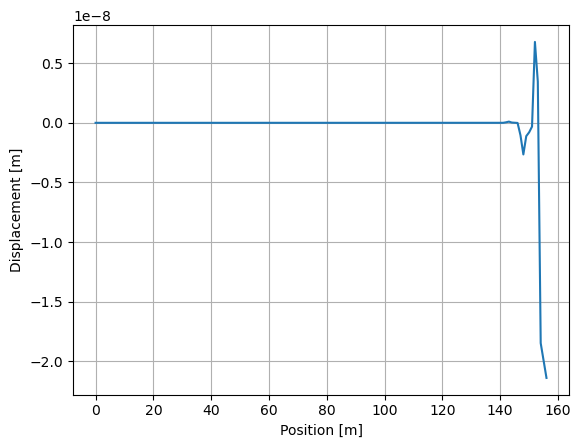

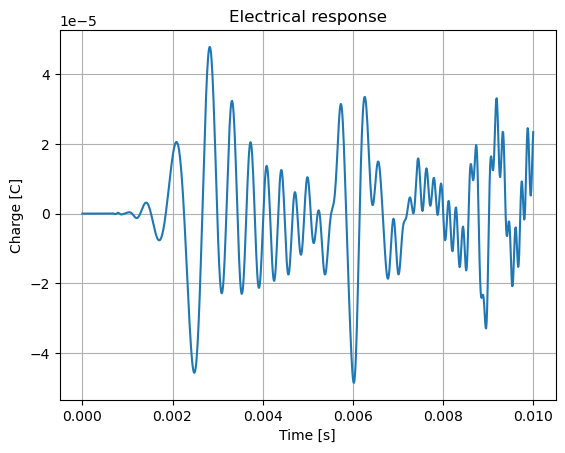

In [36]:


plt.figure()
plt.plot(t, w[:, 120])
plt.xlabel("Time [s]")
plt.ylabel("Displacement [m]")
plt.title("Tip displacement")
plt.grid(True)
plt.show()


plt.figure()
plt.plot( w[1, :])
plt.xlabel("Position [m]")
plt.ylabel("Displacement [m]")
plt.title("")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(t, q[:, 0])
plt.xlabel("Time [s]")
plt.ylabel("Charge [C]")
plt.title("Electrical response")
plt.grid(True)
plt.show()


In [31]:
import importlib
from Modeling.models import plotting
importlib.reload(plotting)
amp_idx = -1
plotting.animate_field_1d_pyvista(
	t=sweep_results[amp_idx]['t'][-100:],
	u=sweep_results[amp_idx]['velocity'][-100:, :],
	x=fe.x_nodes[1:],
	filename="./anim/beam_pyvista2.mp4",
	scale=1,
    stride=1,
	ylabel="Displacement [m]",
)


Saving animation: 100%|██████████| 100/100 [00:02<00:00, 49.80it/s]


Saved animation to ./anim/beam_pyvista2.mp4


Saving frame 100/100Saved animation to ./anim/beam_matplotlib2.mp4


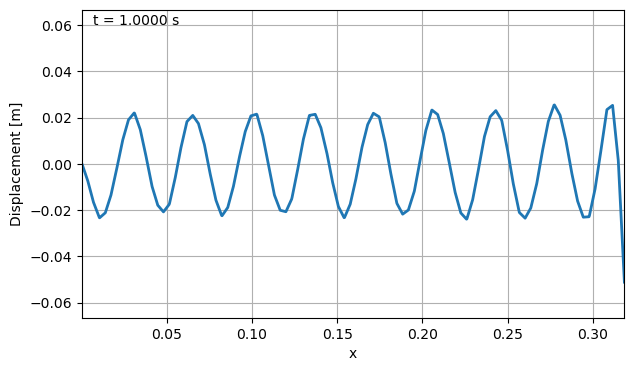

In [32]:
plotting.animate_field_1d(
	t=sweep_results[amp_idx]['t'][-100:],
	u=sweep_results[amp_idx]['velocity'][-100:, :],
	x=fe.x_nodes[1:],
	filename="./anim/beam_matplotlib2.mp4",
	scale=1,
    stride=1,
	ylabel="Displacement [m]",
)
